<img src="images/banner.png" style="width: 100%;">

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Representative-based Clustering

*References*

[1] C. Aggarwal, Data Mining: The Textbook, Chapter 6.

[2] Han, Jiawei, Jian Pei, and Hanghang Tong. *Data mining: concepts and techniques 4th Edition.* Morgan kaufmann, 2023.

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

**Clustering** partitions data points into groups of similar points. It is a rather vague definition and clustering methods differ by their interpretation of this definition. Another major challenge of clustering is cluster validation. Being an unsupervised method, there is no ground truth from which results can be compared. 

When we perform clustering, **there is no guarantee that the resulting clusters will have a specific set of characteristics.** This needs to be emphasized: when we do clustering, we can only say the features that the clustering would be based on (e.g, height, age, weight) but there's no guarantee that the clusters would have specific feature values (young, short and chunky; tall, old and skinny). The only guarantee is that the **objects in a cluster would be similar**.

In this notebook, we will explore **Representative-based clustering methods.** We will also investigate how we can choose the number of clusters $k$ using several internal validation criteria.

## 1 Representative-based Clustering

Representative-based clustering methods is a family of clustering methods wherein a representative point, which may or may not be a data point, is assigned for each cluster. Data points are then assigned to the nearest representative after which a new representative is selected for the cluster. The alternating steps of assigning points to a cluster and selecting a representative is repeated until it converges. The algorithm is written more formally below.

**Algorithm** *GenericRepresentative*(Database: $D$, Number of representatives: $k$)  
**begin**  
$\quad$Initialize representative set $S$;  
$\quad$**repeat**  
$\quad$$\quad$Create clusters ($C_1, ..., C_k$) by assigning each point in $D$ to closest representative in $S$ using the distance function $Dist(\cdot,\cdot)$  
$\quad$$\quad$Recreate set $S$ by determining one representative $y_j$ for each $C_j$ that minimizes $\sum_{x_i \in C_j} Dist(x_i, y_j)$  
$\quad$**until** convergence;  
$\quad$**return** $(C_i, ..., C_k)$;  
**end**

### $k$-means clustering

The simplest and most popular representative-based clustering method is $k$-means clustering. In this method, the distance function $Dist(\cdot,\cdot)$ is the L2-norm or the squared sum error (SSE), which is just the square of the L2 norm. The representative is chosen to be the mean of the points in the cluster.

Why the mean? Representative-based clustering methods, with $k$ clusters, actually try to minimize the objective function $Q = \sum_{j=1}^k Q_j$ where $Q_j = \sum_{x_i \in C_j} Dist(x_i, y_j)$. For $k$-means, 

$$
Q_j = \sum_{x_i \in C_j} (x_i - y_j)^2.
$$

What should be the value of $y_j$ to minimize $Q_j$? It turns out, it's the mean.

How are the representatives initially selected? The two most common approaches are: 

* randomly assign each data point to a cluster then compute the cluster mean;
* pick $k$ data points and set them as the cluster representative.

The first approach tends to make the representatives closer to the center while the other approach tends to spread them out. There are slight differences in terms of performance but either can be chosen for most cases.

The algorithm has converged if the cluster labels of points do not change after a step.

## 2 Data Preprocessing

To demonstrate how we perform clustering in Python, let's use proceed and use the `Cars` dataset for illustration along with the dimensionality reduction techniques we've performed in the previous notebooks.

In [3]:
from sklearn.datasets import fetch_openml

### Data Loading and Preprocessing

In [4]:
data = fetch_openml(data_id=455, parser='auto')
X = (data
     .data.drop('model.year', axis=1)
     .dropna()
     .astype(float))
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min-Max Normalization

### Dimensionality Reduction using SVD

In [5]:
from sklearn.decomposition import TruncatedSVD

from utils import plot_energy_ratio

In [6]:
svd = TruncatedSVD(n_components=X.shape[1])
svd.fit(X);

In [7]:
singular_vectors = pd.DataFrame(
    svd.components_, columns=X.columns,
    index=[f'SV {i + 1}' for i in range(X.shape[1])]
)
X_transformed = pd.DataFrame(svd.transform(X), columns=singular_vectors.index)

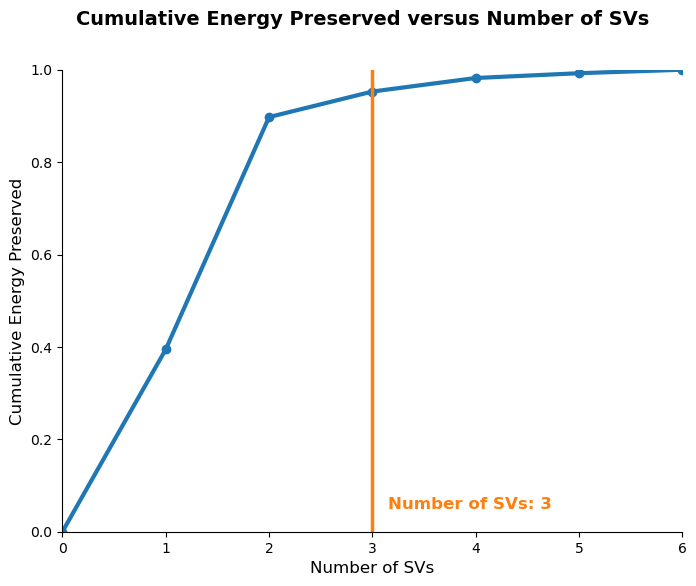

In [8]:
fig, ax, thresh = plot_energy_ratio(svd.explained_variance_ratio_);

In [9]:
X_truncated = X_transformed.iloc[:, :thresh]

In [10]:
X_truncated

,SV 1,SV 2,SV 3
0,1.350263,-0.345657,-0.106722
1,1.448366,-0.490060,-0.135392
2,1.368422,-0.402754,-0.189149
3,1.361263,-0.394222,-0.114938
4,1.315991,-0.416739,-0.170464
...,...,...,...
387,0.714119,0.371198,-0.018870
388,0.860635,1.073426,0.078222
389,0.593218,0.355738,-0.286517
390,0.736266,0.519390,0.087338


In [11]:
X.shape

(392, 6)

## 3 Clustering Analysis

In [12]:
from utils import plot_principal_components

From our previous result, we've hypothesized that using SVD shows three noticable clusters, let's see if using $k$-Means reproduces our intuition.

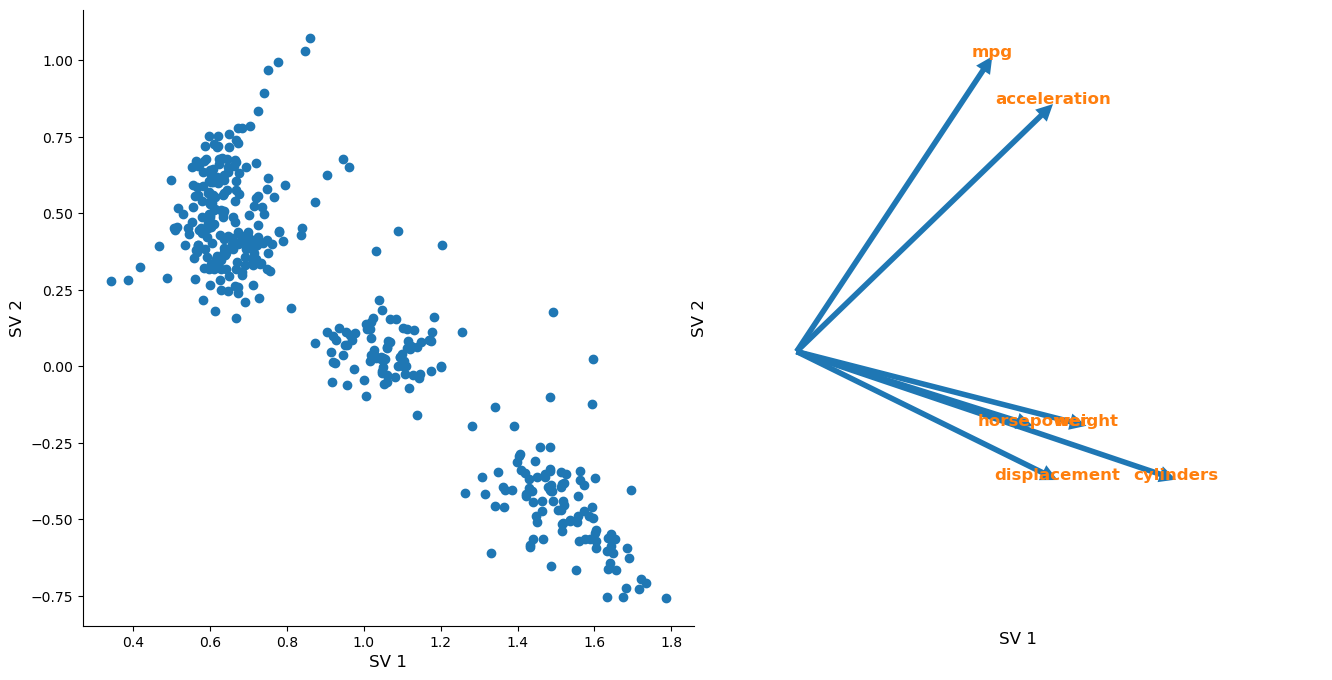

In [13]:
fig, axes = plot_principal_components(X_transformed, singular_vectors, 'SV 1', 'SV 2')
axes[1].set_ylim(singular_vectors.min().min(), singular_vectors.max().max())
axes[1].set_xlim(singular_vectors.min().min() + 0.5, singular_vectors.max().max());

In `sklearn`, the `KMeans` class performs $k$-means clustering and it follows the usual fit and predict paradigm.

In [14]:
from sklearn.cluster import KMeans

In [15]:
kmeans = KMeans(n_clusters=3, random_state=1337, n_init='auto')

In [16]:
kmeans.fit(X_truncated)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1337
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [17]:
cluster_labels = kmeans.predict(X_truncated)

In [19]:
cluster_labels.shape

(392,)

In [20]:
X_truncated.shape

(392, 3)

We can retrieve the cluster centers using the `cluster_centers_` attribute of the clustering object.

In [21]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=X_truncated.columns
)

In [22]:
cluster_centers

,SV 1,SV 2,SV 3
0,1.519184,-0.467886,-0.043944
1,0.646741,0.495139,-0.030875
2,1.069744,0.056942,0.094827


In [23]:
from utils import plot_clustering

In [24]:
help(plot_clustering)

Help on function plot_clustering in module utils:

plot_clustering(data, column_1, column_2, labels, cluster_centers=None)
    Return a visualization plot of the clustering given data points,
    cluster labels, and selected columns.

    Parameters
    ----------
    data : pandas DataFrame
        Data points with columns as features
    column_1 : str
        Feature column to be used as x-axis in plotting
    column_2 : str
        Feature column to be used as y-axis in plotting
    labels : numpy array
        Cluster labels
    cluster_centers : pandas DataFrame, default=None
        Optionally, cluster centers can be included in the plot

    Returns
    -------
    fig : matplotlib Figure
        Figure of the visualization
    ax : matplotlib Axes
        Axes of the visualization



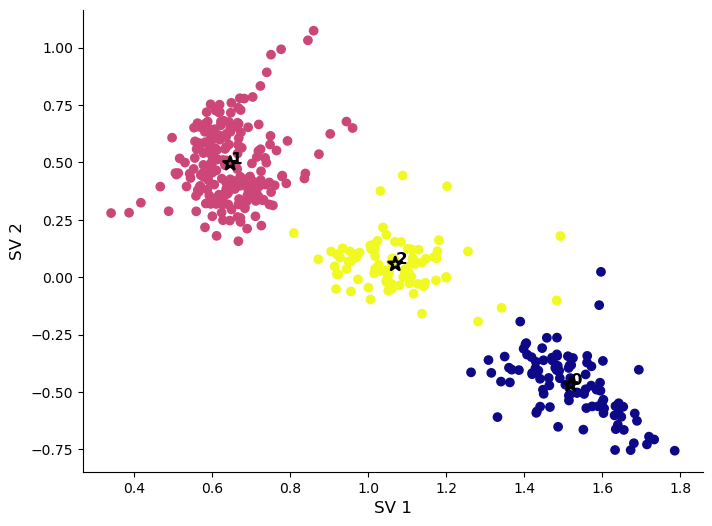

In [25]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', cluster_labels, cluster_centers);

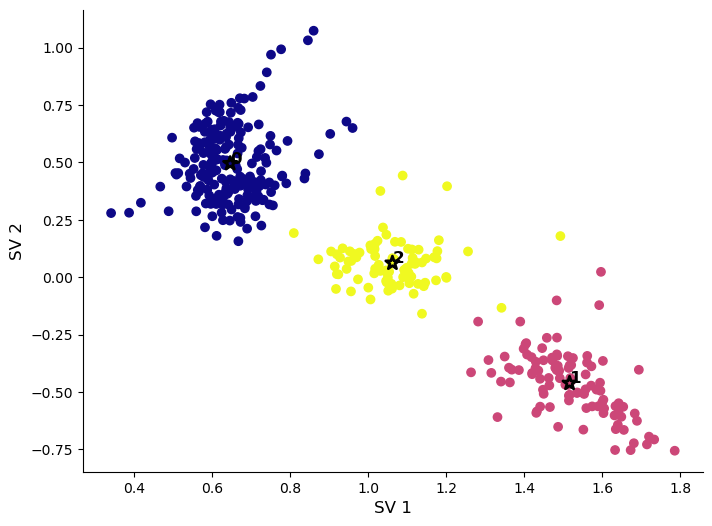

In [30]:
kmeans = KMeans(n_clusters=3, random_state=2, n_init='auto')
kmeans.fit(X_truncated)
cluster_labels = kmeans.predict(X_truncated)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=X_truncated.columns
)
plot_clustering(X_truncated, 'SV 1', 'SV 2', cluster_labels, cluster_centers);

### Determining the Number of Clusters

From the previous plot, we've been able to verify our hypothesis that $k=3$ number of clusters fits well into the dataset. However, in most cases, this is usually unknown. $k$ is often dependent on the shape and scale of distribution of points and the desired clustering resolution.

There are several ways in which we can estimate the number of clusters, which we will demonstrate in the next few cells.

#### Elbow Method

The **elbow method** is based on the insight that increasing the number of clusters will reduce the **sum of within-cluster variance** or **inertia** of each cluster. Since having more clusters, allows one to capture finer group of objects that are similar to one another. However, there is a marginal effect of this reduction. As such, a heuristic for selecting the number of clusters is to use the turning point in the curve of inertia with respect to the number of clusters.

In [37]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Results container
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of cluster setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(X_truncated)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

In [38]:
from utils import plot_internal_metric

In [39]:
help(plot_internal_metric)

Help on function plot_internal_metric in module utils:

plot_internal_metric(k_range, metric_mean, metric_std, metric_name, ebar_scale=10, color='tab:blue')
    Return a visualization plot of the internal validation metric

    Parameters
    ----------
    k_range : list-like
        Number of cluster setting per metric measurement
    metric_mean : array-like
        Array containing the mean of the metric per number of cluster
        setting
    metric_std : array-like
        Array containing the std of the metric per number of cluster
        setting
    metric_name : str
        Metric name to be used as label
    ebar_scale : int or float
        Scale of the plotted error bar as filled area

    Returns
    -------
    fig, ax : matplotlib Figure and Axes



(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Number of Clusters', ylabel='Inertia'>)

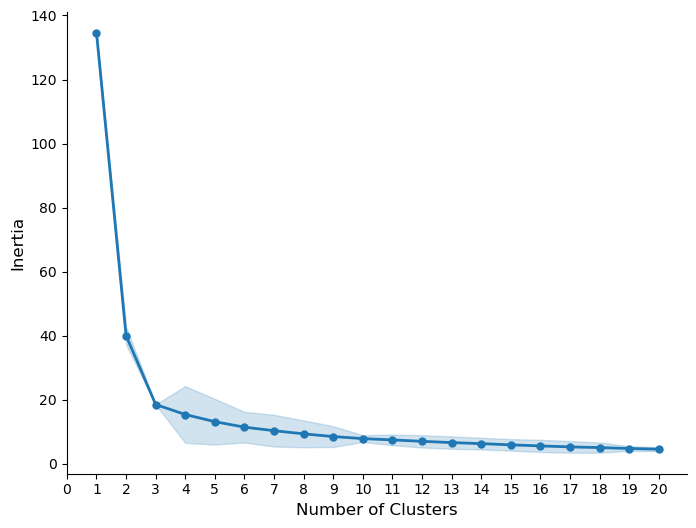

In [42]:
plot_internal_metric(k_range, inertias_mean, inertias_std, "Inertia", 10)

#### Calinski-Harabasz Index

Another way to estimate the number of clusters in a given data set is to look at internal validation metrics. One of which is the **Calinski-Harabasz** index, also known as the **Variance Ratio Criterion**.

Let $B(k)$ and $W(k)$ be the sum of squares of distances between and within clusters respectively,

$$
B(k) = \sum_{i=1}^k n_i || \overline{x_i} - \overline{x} ||^2_2
$$

$$
W(k) = \sum_{i=1}^k \sum_{x \in C_i} || x - \overline{x_i} ||^2_2
$$

The Calinski-Harabasz index is given by,

$$
CH(k) = \frac{\frac{B(k)}{k - 1}}{\frac{W(k)}{n - k}}
$$

In Python, the computation of Calinski-Harabasz score is implemented by `sklearn.metrics`

In [43]:
from sklearn.metrics import calinski_harabasz_score

In [44]:
# Set number of trials
num_trials = 10
k_range = range(2, 21)

# Set results container - mean and std of CH score per trial
chs_mean = []
chs_std = []
for k in k_range:
    chs = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(X_truncated)
        chs.append(calinski_harabasz_score(X_truncated, cluster_labels))
    chs_mean.append(np.mean(chs))
    chs_std.append(np.std(chs))
chs_mean = np.array(chs_mean)
chs_std = np.array(chs_std)

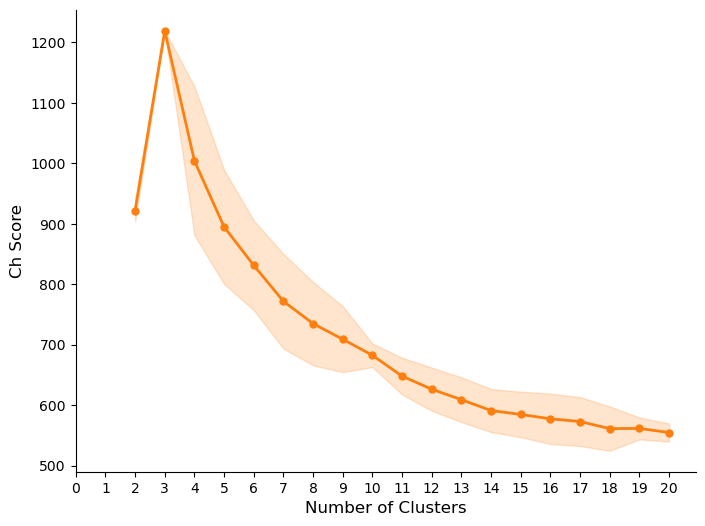

In [46]:
plot_internal_metric(k_range, chs_mean, chs_std, 'CH Score', ebar_scale=2,
                     color='tab:orange');

In this case, both the Elbow method and the CH score points to `3` as the number of clusters in the data set.

### Final Clustering

To obtain the final clustering, we perform the $k$-means algorithm multiple times with different initial cluster centers, then select the best initialization as our chosen grouping. We choose the clustering with the smallest within-cluster variation for this demonstration.

In [47]:
# Hyperparameters
num_trials = 20
k = 3

inertias = []
for i in range(num_trials):
    cur_kmeans = KMeans(n_clusters=k, random_state=i)
    cluster_labels = cur_kmeans.fit_predict(X_truncated)
    inertias.append(cur_kmeans.inertia_)

In [49]:
np.argmin(inertias)

np.int64(2)

In [50]:
min(inertias)

18.519972741592195

In [51]:
inertias[np.argmin(inertias)]

18.519972741592195

In [52]:
# Optimal seting
kmeans = KMeans(n_clusters=k, random_state=np.argmin(inertias))
cluster_labels = kmeans.fit_predict(X_truncated)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=X_truncated.columns
)

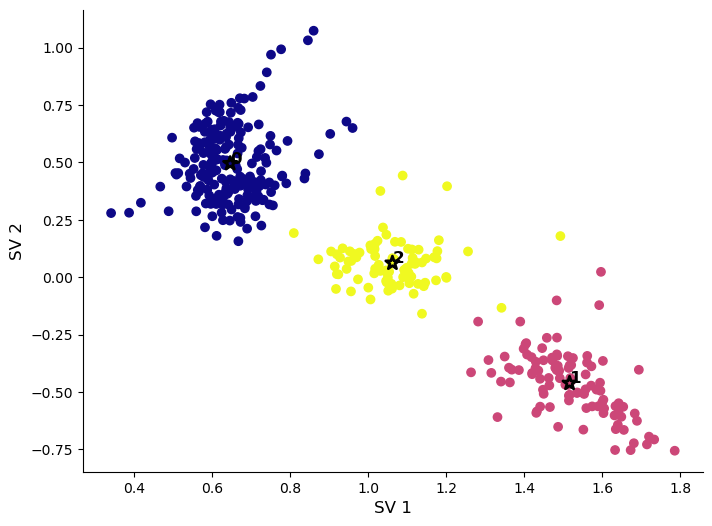

In [53]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', cluster_labels, cluster_centers);

### Post-Clustering EDA

Finally, we interpret the resulting clusters by visualizing the key features of each clusters.

In [54]:
import matplotlib as mpl

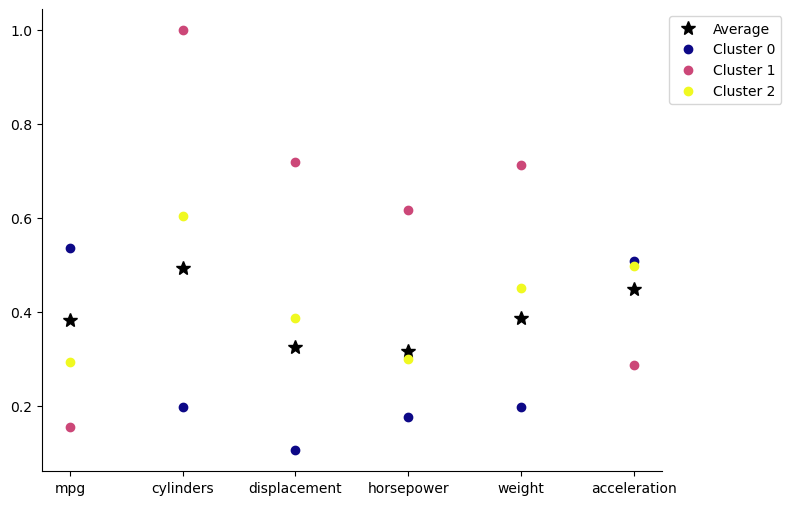

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
X.mean(axis=0).plot(style='*', ax=ax, color='black', markersize=10, label='Average')
for i in np.unique(cluster_labels):
    X.loc[cluster_labels == i].mean(axis=0).plot(
        style='o', ax=ax, color=mpl.colormaps['plasma'].resampled(3).colors[i],
        label=f'Cluster {i}'
    )

ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1., 1.,));

In [56]:
data['target']

0      1
1      1
2      1
3      1
4      1
      ..
401    1
402    2
403    1
404    1
405    1
Name: origin, Length: 406, dtype: category
Categories (3, object): ['1', '2', '3']

In [61]:
origin = (data['target'].loc[X.index]).astype(int) - 1
origin

0      0
1      0
2      0
3      0
4      0
      ..
401    0
402    1
403    0
404    0
405    0
Name: origin, Length: 392, dtype: int64

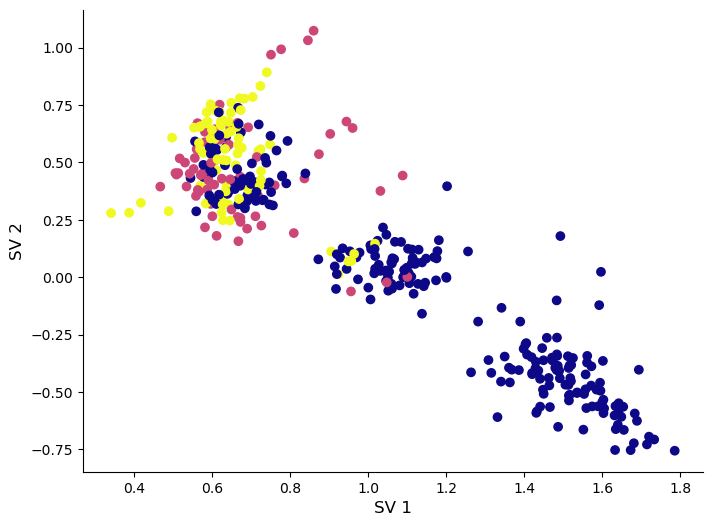

In [62]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', origin);

In [57]:
print(data['DESCR'])

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Committee on Statistical Graphics of the American Statistical
Association (ASA) invites you to participate in its Second (1983)
Exposition of Statistical Graphics Technology. The purposes of the
Exposition are (l) to provide a forum in which users and providers of
statistical graphics technology can exchange information and ideas and
(2) to expose those members of the ASA community who are less familiar
with statistical graphics to its capabilities and potential benefits
to them. The Exposition wil1 be held in conjunction with the Annual
Meetings in Toronto, August 15-18, 1983 and is tentatively scheduled
for the afternoon of Wednesday, August 17.

Seven providers of statistical graphics technology participated in the
l982 Exposition. By all accounts, the Exposition was well received by
the ASA community and was a worthwhile experience for the
participants. We hope to have those seven involved again this year,

<img src="images/banner-down.png" style="width: 100%;">